In [ ]:
import json
import os

# Create kaggle.json
kaggle_dict = {
    "username": "krishnaananyamalladi",
    "key": "KGAT_9958cf9ef6ab9a6c678d7163f0bb50fe"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_dict, f)

# Move to kaggle folder
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Test API
!kaggle datasets list

# Download dataset
!kaggle datasets download -d datamunge/sign-language-mnist

# Unzip
!unzip sign-language-mnist.zip

ref                                                                 title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset              Screen Time, Sleep & Stress Analysis Dataset           787136  2026-02-13 06:56:18.757000          10499        204  1.0              
amar5693/student-performance-dataset                                Student Performance Dataset                            177286  2026-02-12 06:04:44.613000           8917        144  1.0              
aliiihussain/amazon-sales-dataset                                   Amazon_Sales_Dataset                                  1297759  2026-02-01 11:37:12.353000          10358        156  1.0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir()


['.config',
 'amer_sign2.png',
 'sign_mnist_test.csv',
 'american_sign_language.PNG',
 'sign_mnist_train.csv',
 'amer_sign3.png',
 'sign_mnist_test',
 'drive',
 'sign-language-mnist.zip',
 'sign_mnist_train',
 'sample_data']

In [ ]:
import pandas as pd

train_df = pd.read_csv("sign_mnist_train.csv")
test_df  = pd.read_csv("sign_mnist_test.csv")


In [ ]:
train_df.shape

(27455, 785)

In [ ]:
test_df.shape

(7172, 785)

In [ ]:
num_labels = train_df["label"].nunique()
print("Number of labels:", num_labels)


Number of labels: 24


train_df["label"].unique()


In [ ]:
print(train_df["label"].unique())


[ 3  6  2 13 16  8 22 18 10 20 17 19 21 23 24  1 12 11 15  4  0  5  7 14]


In [ ]:
label_counts = train_df["label"].value_counts()
print(label_counts)


label
17    1294
16    1279
11    1241
22    1225
5     1204
18    1199
14    1196
3     1196
19    1186
23    1164
8     1162
20    1161
13    1151
2     1144
0     1126
24    1118
10    1114
6     1090
15    1088
21    1082
12    1055
7     1013
1     1010
4      957
Name: count, dtype: int64


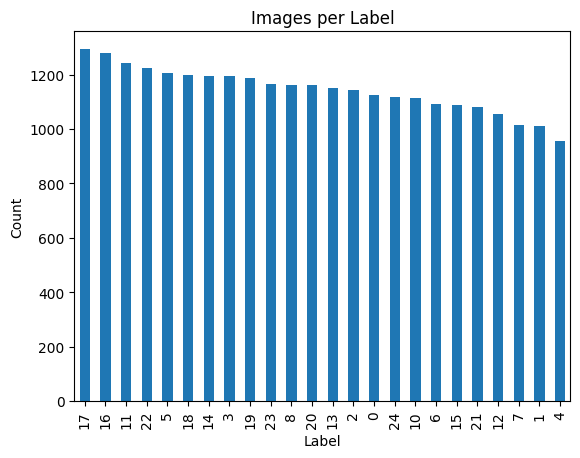

In [ ]:
import matplotlib.pyplot as plt

label_counts.plot(kind="bar")
plt.title("Images per Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


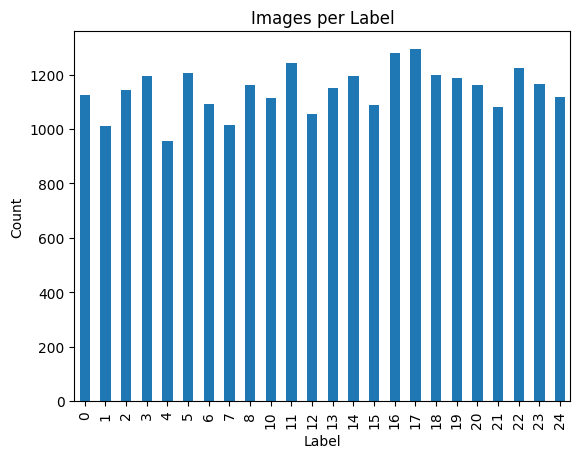

In [ ]:
import matplotlib.pyplot as plt
label_counts=label_counts.sort_index()
label_counts.plot(kind="bar")
plt.title("Images per Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


In [ ]:
train_df = train_df.to_numpy().reshape(-1, 28, 28, 1)


ValueError: cannot reshape array of size 21552175 into shape (28,28,1)

In [ ]:
X_train = train_df.drop("label", axis=1)


In [ ]:
X_train = X_train.values

In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1)

In [ ]:
Y_test=test_df.drop("label",axis=1)

In [ ]:
Y_test=Y_test.values

In [ ]:
type(X_train)

numpy.ndarray

#till the above are all preprocessing steps

In [ ]:
X_train=X_train/(255.0)

In [ ]:
Y_test=Y_test/(255.0)

In [ ]:
print(type(X_train))


<class 'numpy.ndarray'>


In [ ]:
z_train=train_df["label"]

In [ ]:
z_test=test_df["label"]

In [ ]:
from tensorflow.keras.utils import to_categorical

z_train = to_categorical(z_train)
z_test  = to_categorical(z_test)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout


In [ ]:
model = Sequential()


In [ ]:
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(28,28,1)
))


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras import Input

model = Sequential()

# Input Layer
model.add(Input(shape=(28,28,1)))

# Conv Block 1
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

# Conv Block 2
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))

# Output
model.add(Dense(24,activation='softmax'))


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train,
    z_train,
    epochs=10,
    batch_size=32,
    validation_data=(Y_test, z_test)
)


In [ ]:
print(X_train.shape)


(27455, 28, 28, 1)


In [ ]:
X_train = train_df.drop("label", axis=1)
y_train = train_df["label"]


In [ ]:
X_train = X_train.values


In [ ]:
X_test = test_df.drop("label", axis=1)
y_test = test_df["label"]

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/10


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("sequential_1_1/Cast:0", shape=(None, 784), dtype=float32). Expected shape (None, 28, 28, 1), but input has incompatible shape (None, 784)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 784), dtype=int64)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
# TRAIN
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"]

X_train = X_train.reshape(-1, 28, 28, 1)
X_train = X_train / 255.0

# TEST
X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"]

X_test = X_test.reshape(-1, 28, 28, 1)
X_test = X_test / 255.0


In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test  = to_categorical(y_test)


In [ ]:
print(X_train.shape)
print(y_train.shape)


(27455, 28, 28, 1)
(27455, 25)


In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = train_df["label"]
y_test  = test_df["label"]

y_train = to_categorical(y_train)
y_test  = to_categorical(y_test)

print(y_train.shape)


(27455, 25)


In [ ]:
print("Unique label count:", train_df["label"].nunique())
print("Unique labels:", sorted(train_df["label"].unique()))


Unique label count: 24
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


In [ ]:
print("Max label:", train_df["label"].max())


Max label: 24


In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


X_train: (27455, 28, 28, 1)
y_train: (27455, 25)
X_test : (7172, 28, 28, 1)
y_test : (7172, 25)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/10


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None, 25), output.shape=(None, 26, 26, 32)

In [ ]:
model = Sequential()

model.add(Input(shape=(28,28,1)))

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))

# 🔴 FIX HERE
model.add(Dense(25, activation='softmax'))


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/8
858/858 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.7434 - loss: 0.7958 - val_accuracy: 0.9077 - val_loss: 0.3040
Epoch 2/8
858/858 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9556 - loss: 0.1468 - val_accuracy: 0.9448 - val_loss: 0.1675
Epoch 3/8
858/858 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9781 - loss: 0.0685 - val_accuracy: 0.9255 - val_loss: 0.2206
Epoch 4/8
858/858 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.9868 - loss: 0.0417 - val_accuracy: 0.9207 - val_loss: 0.2246
Epoch 5/8
858/858 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.9896 - loss: 0.0331 - val_accuracy: 0.9363 - val_loss: 0.1902
Epoch 6/8
858/858 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9937 - loss: 0.0225 - val_accuracy: 0.9421 - val_loss: 0.2658
Epoch 7/8
858/858 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9915 - loss: 0.0235 - val_accuracy: 0.9380 - val_loss: 0.2573
Epoch 8/8
858/858 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9942 - loss: 0.0182 - val_accu

In [ ]:
model.save("sign_language_cnn")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
model.save('/content/drive/MyDrive/sign_language_cnn.h5')


In [ ]:
# Evaluate on training data
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)

# Evaluate on testing data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Training Accuracy : {train_acc:.4f}")
print(f"Training Loss     : {train_loss:.4f}")
print(f"Testing Accuracy  : {test_acc:.4f}")
print(f"Testing Loss      : {test_loss:.4f}")


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("sign_language_cnn.h5")


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("sign_language_cnn.h5")

# Label mapping (edit based on your dataset)
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

# Start webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    # Draw ROI square
    cv2.rectangle(frame,(100,100),(400,400),(0,255,0),2)

    # Crop ROI
    roi = frame[100:400, 100:400]

    # Convert to grayscale (since training was grayscale)
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    # Resize to CNN input size
    img = cv2.resize(gray,(128,128))

    # Normalize pixel values
    img = img / 255.0

    # Add channel axis + batch axis
    img = np.reshape(img,(1,128,128,1))

    # Predict
    pred = model.predict(img)
    class_index = np.argmax(pred)
    label = labels[class_index]

    # Display prediction text
    cv2.putText(frame,label,(100,90),
                cv2.FONT_HERSHEY_SIMPLEX,
                2,(0,255,0),3)

    # Show webcam
    cv2.imshow("Sign Detection",frame)
    cv2.imshow("ROI",roi)
    cv2.imshow("Gray",gray)

    # Exit on ESC
    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()


In [ ]:
from google.colab import files
files.download("sign_language_cnn.h5")


In [ ]:
model.save("sign_language_model", save_format="tf")

In [ ]:
from google.colab import files
files.download("sign_language_model")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
os.listdir("kaggle/working")

FileNotFoundError: [Errno 2] No such file or directory: 'kaggle/working'

In [ ]:
print(os.getcwd())

/content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model.export("/content/drive/MyDrive/sign_language_model")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved artifact at '/content/drive/MyDrive/sign_language_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_39')
Output Type:
  TensorSpec(shape=(None, 25), dtype=tf.float32, name=None)
Captures:
  139976548083152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139976548082768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139976548083536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139976548084112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139976548081232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139976548084496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139976548085072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139976548079504: TensorSpec(shape=(), dtype=tf.resource, name=None)

In [ ]:
!zip -r sign_language_model.zip sign_language_model

  adding: sign_language_model/ (stored 0%)
  adding: sign_language_model/saved_model.pb (deflated 85%)
  adding: sign_language_model/variables/ (stored 0%)
  adding: sign_language_model/variables/variables.index (deflated 61%)
  adding: sign_language_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: sign_language_model/fingerprint.pb (stored 0%)
  adding: sign_language_model/assets/ (stored 0%)


In [ ]:
from google.colab import files
files.download("sign_language_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save("sign_language_model.keras")

In [ ]:
from google.colab import files
files.download("sign_language_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import keras
print(keras.__version__)

import tensorflow as tf
print(tf.__version__)

3.10.0
2.19.0
